In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Explore and load the store data

| | |
|-|-|
| Author(s) | [Matt Robinson](https://github.com/mr394729) |

> **This copy keeps the output of one complete run** (24 September 2026, in a test namespace), so you can read what each cell prints even if a cell fails for you. Your numbers and wording will differ where a model answers. To start clean, choose **Edit > Clear Outputs of All Cells** in JupyterLab, or run `jupyter nbconvert --clear-output --inplace <notebook>`.

## Overview

### Store operations

A store team makes the same kinds of decisions every morning. The agent in this workshop supports five of them, and each one needs different evidence:

| Responsibility | The decision | The evidence |
|---|---|---|
| Store manager | What needs attention first? | Inventory, pickups, coverage, guest feedback, incidents |
| Associate orchestration | Who can take the next task? | Skills, current work, breaks and pickup promises |
| Inventory excellence | What can be picked or replenished? | Stock, reservations, location and inbound supply |
| Loss and damage prevention | What needs investigating? | Dated events, control checks and existing work |
| Associate development | What support would help? | Dated activity, comparable measures and completed learning |

### The dataset

Cymbal Beauty and its records are fictional. A deterministic generator in the repository (`data/generate.py`) produces thirteen tables, so everyone in the workshop works with the same 600 products, the same 2,000 pickup orders and the same people.

The store clock is fixed at **9:00 AM on Saturday 3 October 2026, America/Chicago**, so every notebook sees the same morning. Today's traffic is a forecast; earlier dates are history.

In the workshop the data lives in [BigQuery](https://cloud.google.com/bigquery/docs/introduction), one dataset per person and environment, named `cymbal_beauty_<namespace>_dev`.

### Objectives

In this tutorial, you will learn what the agent's data looks like and put your own copy of it in BigQuery.

You will complete the following tasks:

- Generate the thirteen tables and profile them
- Look at one store's stock and trading history
- Load the tables into a BigQuery dataset in your namespace
- Give your deployed agent access to the dataset
- Query the loaded data with SQL

### Costs

This tutorial uses billable components of Google Cloud:

- BigQuery

Learn about [BigQuery pricing](https://cloud.google.com/bigquery/pricing) and use the [Pricing Calculator](https://cloud.google.com/products/calculator/) to generate a cost estimate based on your projected usage.

## Get started

### Set Google Cloud project information

This notebook loads data into your own namespace. Set your project ID and the namespace you chose in notebook 00.

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ID = "[your-project-id]"  # @param {type: "string"}
WORKSHOP_NAMESPACE = "[your-namespace]"  # @param {type: "string"}

if PROJECT_ID == "[your-project-id]":
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "")
if WORKSHOP_NAMESPACE == "[your-namespace]":
    WORKSHOP_NAMESPACE = os.environ.get("WORKSHOP_NAMESPACE", "")
if not PROJECT_ID or not WORKSHOP_NAMESPACE:
    raise ValueError("Set PROJECT_ID and WORKSHOP_NAMESPACE above.")

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["WORKSHOP_NAMESPACE"] = WORKSHOP_NAMESPACE
os.environ["GOOGLE_CLOUD_LOCATION"] = "global"
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "TRUE"
os.environ["STORE_OPS_ENV"] = "dev"

# The agent's code lives one folder up from this notebook
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

### Import libraries

In [3]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from google.cloud import bigquery

from data.generate import generate_all

## Generate the data

`generate_all()` builds every table in memory from one seeded random generator and returns a dictionary of table name to rows. Nothing is written yet.

In [4]:
tables = generate_all()

profile = pd.DataFrame(
    [
        {"table": name, "rows": len(rows), "columns": len(rows[0])}
        for name, rows in tables.items()
    ]
)
profile

,table,rows,columns
0,products,600,15
1,reviews,6000,7
2,stores,40,11
3,store_inventory,24000,9
4,associates,200,8
5,store_tasks,400,12
6,bopis_orders,2000,6
7,store_traffic,6720,5
8,shrink_events,1500,7
9,guest_feedback,800,6


Every run produces the same thirteen tables. They range from 16 rows in `operations_context` to 24,000 in `store_inventory`, one row for each of the 600 products in each of the 40 stores.

The tables fall into three groups: the catalog (products, reviews, stores), store operations (inventory, tasks, pickup orders, replenishment) and activity over time (traffic, loss events, guest feedback, coaching signals). A logarithmic scale shows how different their sizes are:

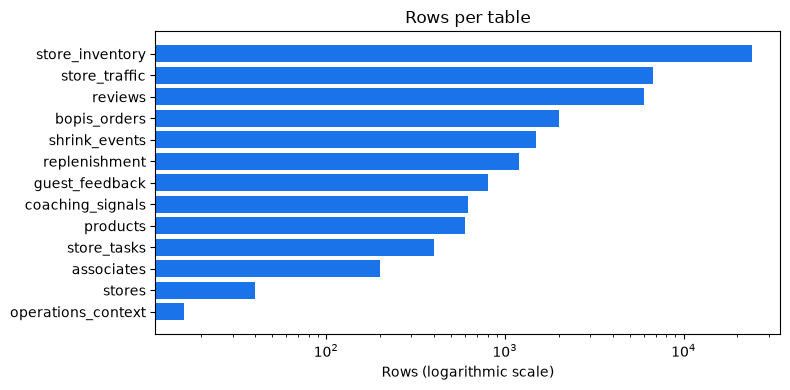

In [5]:
ordered = profile.sort_values("rows")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ordered["table"], ordered["rows"], color="#1a73e8")
ax.set_xscale("log")
ax.set_xlabel("Rows (logarithmic scale)")
ax.set_title("Rows per table")
fig.tight_layout()
plt.show()

## Look at one store

Store S-014 in Naperville is the store the workshop uses. Join the catalog to the store's inventory on `product_id`. Product IDs are the key throughout the data, because two products can share a display name.

`on_shelf_qty` and `backroom_qty` are recorded balances. They don't say how many units a guest can be promised, because some units may be reserved for pickup orders. The agent reads reservations separately for that reason.

600 products, 5,874 units on hand


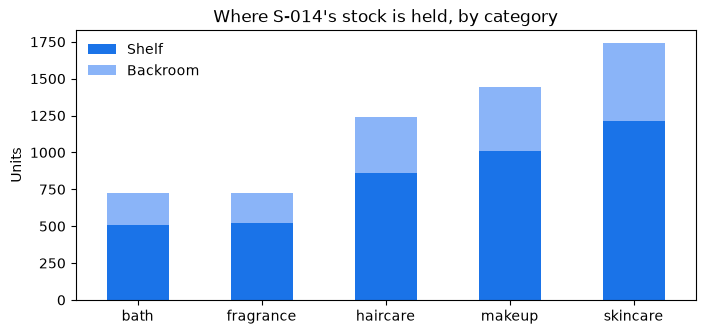

In [6]:
products = pd.DataFrame(tables["products"])
inventory = pd.DataFrame(tables["store_inventory"])

store = inventory[inventory["store_id"] == "S-014"].merge(products, on="product_id")
print(f"{store['product_id'].nunique()} products, {store['on_hand'].sum():,} units on hand")

by_category = store.groupby("category")[["on_shelf_qty", "backroom_qty"]].sum()
ax = by_category.plot.bar(stacked=True, rot=0, figsize=(8, 3.5), color=["#1a73e8", "#8ab4f8"])
ax.set(xlabel="", ylabel="Units", title="Where S-014's stock is held, by category")
ax.legend(["Shelf", "Backroom"], frameon=False)
plt.show()

S-014 stocks all 600 products, 5,874 units in total. In every category most of the units are on the shelf.

Filter the store's products by category. Change `CATEGORY` to `skincare`, `fragrance`, `makeup` or `bath` and run the cell again:

In [7]:
CATEGORY = "haircare"  # @param {type: "string"}

columns = ["product_id", "name", "price_usd", "on_hand", "on_shelf_qty", "backroom_qty"]
store[store["category"] == CATEGORY][columns].sort_values("product_id").head(8)

,product_id,name,price_usd,on_hand,on_shelf_qty,backroom_qty
180,P-0181,Lift Shampoo,38.99,8,4,4
181,P-0182,Glow Conditioner,14.99,2,1,1
182,P-0183,Bloom Hair Mask,18.00,17,12,5
183,P-0184,Glow Leave-In,28.00,16,10,6
184,P-0185,Renew Styling Cream,28.00,10,6,4
185,P-0186,Dew Dry Shampoo,95.00,10,5,5
186,P-0187,Bright Shampoo,18.00,8,4,4
187,P-0188,Bright Conditioner,32.00,13,12,1


### Operational snapshots

Some evidence exists only for selected products and people: stock locations, reservations, control checks and learning records. The `operations_context` table holds these snapshots, grouped by the system they come from.

When no snapshot exists, the fact is unknown, not zero. The agent's tools report it as unknown rather than guessing.

In [8]:
operations = pd.DataFrame(tables["operations_context"])

operations.groupby("system").agg(
    snapshots=("subject_id", "count"), subjects=("subject_id", "nunique")
)

,snapshots,subjects
system,,
coverage,1,1
directives,1,1
inventory_allocation,3,3
learning,3,3
loss_controls,1,1
loss_reconciliation,1,1
picking_activity,3,3
stock_location,3,3


Sixteen snapshots across eight systems. Only three products have a recorded stock location, for example, so for any other product the location is unknown.

### Trading history and today's forecast

The `store_traffic` table has hourly visitors, transactions and sales. Convert the timestamps to the store's time zone and total them by day. The last point is today, which is a forecast rather than a result, so a daily trading report uses the last completed day.

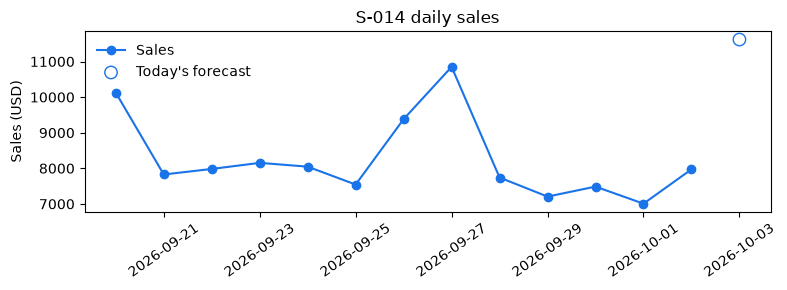

In [9]:
STORE_TODAY = pd.Timestamp("2026-10-03").date()

traffic = pd.DataFrame(tables["store_traffic"])
traffic = traffic[traffic["store_id"] == "S-014"].copy()
traffic["day"] = (
    pd.to_datetime(traffic["ts_hour"], utc=True).dt.tz_convert("America/Chicago").dt.date
)
daily = traffic.groupby("day", as_index=False)["sales_usd"].sum()
history = daily[daily["day"] < STORE_TODAY]
forecast = daily[daily["day"] == STORE_TODAY]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history["day"], history["sales_usd"], marker="o", color="#1a73e8", label="Sales")
ax.scatter(forecast["day"], forecast["sales_usd"], facecolors="none", edgecolors="#1a73e8",
           s=80, label="Today's forecast")
ax.set(ylabel="Sales (USD)", title="S-014 daily sales")
ax.tick_params(axis="x", rotation=35)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Load the data into BigQuery

The deployed agent reads the same records from BigQuery. In this section, you create your dataset and load the thirteen tables into it.

### Create the dataset

The dataset name carries your namespace and the environment, so datasets in a shared project never collide:

In [10]:
bq_client = bigquery.Client(project=PROJECT_ID)

DATASET_ID = f"{PROJECT_ID}.cymbal_beauty_{WORKSHOP_NAMESPACE}_dev"

dataset = bigquery.Dataset(DATASET_ID)
dataset.location = "US"
dataset.labels = {"ns": WORKSHOP_NAMESPACE, "env": "dev"}
dataset = bq_client.create_dataset(dataset, exists_ok=True)
print(f"Dataset: {dataset.full_dataset_id}")

Dataset: mattrobn-sandbox:cymbal_beauty_opsreview_dev


### Load the tables

Each table has a schema file in `data/schemas/`, with a type and a description for every column. The descriptions matter: the agent's data tools show them to the model.

`load_table_from_json` starts one load job per table. The jobs run at the same time in BigQuery; `result()` waits for each one. `WRITE_TRUNCATE` replaces a table if it already exists, so you can run this cell again safely. The thirteen loads take about 10 seconds.

In [11]:
schema_dir = REPO_ROOT / "data" / "schemas"

jobs = {}
for name, rows in tables.items():
    schema_fields = json.loads((schema_dir / f"{name}.json").read_text())
    job_config = bigquery.LoadJobConfig(
        schema=[bigquery.SchemaField.from_api_repr(field) for field in schema_fields],
        write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
    )
    jobs[name] = bq_client.load_table_from_json(rows, f"{DATASET_ID}.{name}", job_config=job_config)

for name, job in jobs.items():
    job.result()
    print(f"{name:20} {job.output_rows:>7,} rows")

products                 600 rows
reviews                6,000 rows
stores                    40 rows


store_inventory       24,000 rows


associates               200 rows
store_tasks              400 rows
bopis_orders           2,000 rows


store_traffic          6,720 rows
shrink_events          1,500 rows
guest_feedback           800 rows


coaching_signals         624 rows
replenishment          1,200 rows
operations_context        16 rows


### Give your deployed agent access

The deployed agent runs as a service account, `store-ops-dev-runtime`. So does the MCP server you start in notebook 05, which is how the deployed agent reads store records. The account needs to read the whole dataset and to write one table, `store_tasks`, which is where approved tasks go. Every other table stays read-only to the agent.

Add the service account to the dataset's access list, then grant it the BigQuery Data Editor role on `store_tasks` alone:

In [12]:
RUNTIME_SERVICE_ACCOUNT = f"store-ops-dev-runtime@{PROJECT_ID}.iam.gserviceaccount.com"

dataset = bq_client.get_dataset(DATASET_ID)
reader = bigquery.AccessEntry(role="READER", entity_type="userByEmail", entity_id=RUNTIME_SERVICE_ACCOUNT)
if reader not in dataset.access_entries:
    dataset.access_entries = [*dataset.access_entries, reader]
    bq_client.update_dataset(dataset, ["access_entries"])

tasks_table = f"{DATASET_ID}.store_tasks"
member = f"serviceAccount:{RUNTIME_SERVICE_ACCOUNT}"
policy = bq_client.get_iam_policy(tasks_table)
if not any(b["role"] == "roles/bigquery.dataEditor" and member in b["members"] for b in policy.bindings):
    policy.bindings.append({"role": "roles/bigquery.dataEditor", "members": {member}})
    bq_client.set_iam_policy(tasks_table, policy)
print(f"{RUNTIME_SERVICE_ACCOUNT} can read the dataset and write store_tasks")

store-ops-dev-runtime@mattrobn-sandbox.iam.gserviceaccount.com can read the dataset and write store_tasks


## Query the data with SQL

Check the load: count the rows in every table with one query and compare the counts with the generator. `__TABLES__` is BigQuery table metadata, so this query reads no table data.

In [13]:
query = f"SELECT table_id, row_count FROM `{DATASET_ID}.__TABLES__`"
loaded = {row["table_id"]: row["row_count"] for row in bq_client.query(query).result()}

check = profile.assign(in_bigquery=profile["table"].map(loaded))
check["match"] = check["rows"] == check["in_bigquery"]
check

,table,rows,columns,in_bigquery,match
0,products,600,15,600,True
1,reviews,6000,7,6000,True
2,stores,40,11,40,True
3,store_inventory,24000,9,24000,True
4,associates,200,8,200,True
5,store_tasks,400,12,400,True
6,bopis_orders,2000,6,2000,True
7,store_traffic,6720,5,6720,True
8,shrink_events,1500,7,1500,True
9,guest_feedback,800,6,800,True


Every table in BigQuery has the same row count as the generator.

Now ask the data a store question. How many pickup orders are waiting at S-014, how many units do they hold, and when is the first one promised?

In [14]:
query = f"""
SELECT
  COUNT(*) AS pending_orders,
  SUM(qty) AS units,
  FORMAT_TIMESTAMP('%I:%M %p', MIN(promised_at), 'America/Chicago') AS first_promise
FROM `{DATASET_ID}.bopis_orders`
WHERE store_id = 'S-014' AND status = 'pending'
"""
pd.DataFrame([dict(row) for row in bq_client.query(query).result()])

,pending_orders,units,first_promise
0,9,13,09:30 AM


Nine pickup orders holding 13 units are waiting, and the first is promised for 9:30 AM. You will see these numbers again in the agent's answers in notebook 02.

The agent answers this question with the same data, through a tool that builds a query like this one from typed parameters. Notebook 03 looks at those tools.

## Cleaning up

The later notebooks use this dataset, so keep it for the workshop. To delete it afterwards, run:

```python
bq_client.delete_dataset(DATASET_ID, delete_contents=True, not_found_ok=True)
```

## What's next

- [Load data with the BigQuery Python client](https://cloud.google.com/bigquery/docs/samples/bigquery-load-table-dataframe)
- [Control access to datasets](https://cloud.google.com/bigquery/docs/control-access-to-resources-iam)
- [The data contracts](../docs/DATA_REQUIREMENTS.md): what each table and column means
- Next notebook: [Multi-agent patterns in the Cymbal Beauty store agent](02_agent_patterns.ipynb)